# 07 — Recomendación Personalizada por Perfil de Riesgo (v6)

## Entradas y salidas

- Carga `nb06_h22_model_results.parquet` y `nb06_volatility_predictions.parquet` (generados por N06a y N06b).
- Guarda `recommendations_v8.parquet` (principal) y `recommendation_engine_v6.json` (metadatos).

## Diseño: segmentación por volatilidad predicha

| Nivel | Pool de candidatas | Objetivo |
|-------|------|----------|
| R1 (Muy Conservador) | 35% carteras con menor vol predicha | Minimizar error de predicción |
| R2 (Conservador) | 55% carteras con menor vol predicha | — |
| R3 (Moderado) | universo completo | Equilibrio |
| R4 (Agresivo) | 55% carteras con mayor vol predicha | — |
| R5 (Muy Agresivo) | 35% carteras con mayor vol predicha | Maximizar retorno esperado |

**Puntuación compuesta:** `score = w_safe · safety_score + w_retorno · p_positiva + w_util · puntuacion_regimen`  
Los pesos (`w_safe`, `w_retorno`, `w_util`) se ajustan dinámicamente en función del régimen de mercado actual.


In [1]:
import sys, json, warnings, importlib
from pathlib import Path
import matplotlib
matplotlib.use('inline' if 'ipykernel' in sys.modules else 'Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('.').resolve()
for p in [ROOT, ROOT.parent]:
    if (p / 'data').exists() and (p / 'src').exists():
        ROOT = p; break
sys.path.insert(0, str(ROOT))

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'data' / 'results'
FIG_DIR       = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

import src.nb07_recommendation as nb07_recommendation
importlib.reload(nb07_recommendation)

from src.nb07_recommendation import (
    build_regime_context, load_pred_vol,
    build_pred_frame_v3, recommend_v5,
    LEVEL_NAMES_V2, VOL_TIER_QUANTILE, MIN_MODEL_AGREEMENT,
 )
print("Modulo cargado OK")

Modulo cargado OK


## 1. Cargar entradas

In [2]:
# Resultados NB06 (predicciones de crecimiento) - carga canónica
model_results, source_version = None, None
for tag, fname in [("v9",        "nb06v9_h22_model_results.parquet"),
                   ("v8",        "nb06v8_h22_model_results.parquet"),
                   ("canonical", "nb06_h22_model_results.parquet")]:
    p = RESULTS_DIR / fname
    if p.exists():
        model_results = pd.read_parquet(p)
        source_version = tag
        print(f"Cargado nb06 {tag}: {model_results.shape}  ({fname})")
        break
if model_results is None:
    raise FileNotFoundError(
        "Ejecuta primero NB06a-v2 (genera nb06_h22_model_results.parquet)")

ens_cols = [c for c in model_results.columns if c.startswith("ENS_")]
print(f"  Columnas ENS disponibles: {ens_cols}")

# Contexto de régimen (HMM)
regime_df = pd.read_parquet(PROCESSED_DIR / "hmm_regime_features.parquet")
regime_context = build_regime_context(regime_df, PROCESSED_DIR / "hmm_state_labels.json")

# Volatilidad predicha (NB06b)
pred_vol_series, vol_model_used = load_pred_vol(RESULTS_DIR)
vol_available = len(pred_vol_series) > 0
print(f"Vol model: {vol_model_used}  |  Disponible: {vol_available}")

# Prediction frame (une crecimiento + vol + régimen)
pred_frame, _ = build_pred_frame_v3(model_results, pred_vol_series, regime_context["current_regime_id"])
print(f"Prediction frame: {pred_frame.shape}")
print(f"  p_positive:  [{pred_frame.p_positive.min():.3f}, {pred_frame.p_positive.max():.3f}]")
print(f"  growth_pred: [{pred_frame.growth_pred.min():.4f}, {pred_frame.growth_pred.max():.4f}]")


Cargado nb06 v9: (40, 57)  (nb06v9_h22_model_results.parquet)
  Columnas ENS disponibles: ['ENS_growth', 'ENS_precision', 'ENS_w_m1', 'ENS_w_m2', 'ENS_w_m3', 'ENS_w_m4', 'ENS_mape_pct', 'ENS_brier_dir', 'ENS_sharpe', 'ENS_sortino', 'ENS_maxdd']
Regime: 'Transition' (state 2)  rrs=0.268  prob_bear_22d=0.0000
Vol predictions: model=CAT_vol, fold=3, n=40, range=[0.029, 0.081]
Vol model: CAT_vol  |  Disponible: True
Vol (historical fallback): 40 portfolios, range=[0.045, 0.198]
Prediction frame: (40, 16)
  p_positive:  [0.251, 0.400]
  growth_pred: [-0.0006, 0.0120]


In [3]:
# Consensus signals from individual model predictions
consensus_cols = ['direction_consensus', 'model_agreement', 'best_model_growth',
                  'M1_growth', 'M2_growth', 'M3_growth', 'M4_growth']
avail_cols = [c for c in consensus_cols if c in pred_frame.columns]
if avail_cols:
    print('=== Senales de consenso por cartera ===')
    display(pred_frame[avail_cols].round(4).sort_values('direction_consensus', ascending=False))
    print(f'  direction_consensus medio: {pred_frame["direction_consensus"].mean():.3f}')
    print(f'  model_agreement medio:     {pred_frame["model_agreement"].mean():.3f}')
    n_full_agree = (pred_frame['direction_consensus'] == 1.0).sum()
    print(f'  Carteras con todos los modelos de acuerdo (dir): {n_full_agree}')
else:
    print('[WARN] No se encontraron columnas de consenso en pred_frame')


=== Senales de consenso por cartera ===


,direction_consensus,model_agreement,best_model_growth,M1_growth,M2_growth,M3_growth,M4_growth
1,1.00,0.5098,0.0080,0.0060,0.0078,0.0018,0.0080
3,1.00,0.4159,0.0107,0.0071,0.0107,0.0013,0.0089
8,1.00,0.3146,0.0090,0.0090,0.0041,0.0009,0.0085
9,1.00,0.3629,0.0128,0.0085,0.0128,0.0018,0.0060
10,1.00,0.3434,0.0076,0.0076,0.0071,0.0001,0.0065
14,1.00,0.3635,0.0062,0.0052,0.0055,0.0002,0.0062
55,1.00,0.4016,0.0115,0.0075,0.0115,0.0012,0.0088
134,1.00,0.4215,0.0032,0.0025,0.0025,0.0003,0.0032
1449,1.00,0.3463,0.0047,0.0047,0.0044,0.0005,0.0025
183,1.00,0.3997,0.0178,0.0100,0.0176,0.0027,0.0178


  direction_consensus medio: 0.950
  model_agreement medio:     0.360
  Carteras con todos los modelos de acuerdo (dir): 36


## 2. Distribución de tiers de volatilidad

In [4]:
if vol_available:
    vol = pred_frame['pred_ann_vol'].dropna()
    print(f"Vol predicha: min={vol.min():.3f}  q33={vol.quantile(.33):.3f}  "
          f"median={vol.median():.3f}  q67={vol.quantile(.67):.3f}  max={vol.max():.3f}")
    for rl, (q_lo, q_hi) in VOL_TIER_QUANTILE.items():
        lo = vol.quantile(q_lo) if q_lo > 0 else -float('inf')
        hi = vol.quantile(q_hi) if q_hi < 1 else float('inf')
        n  = int(((vol >= lo) & (vol <= hi)).sum())
        lo_s = f"{lo:.3f}" if lo > -1e9 else "-inf"
        hi_s = f"{hi:.3f}" if hi <  1e9 else "+inf"
        print(f"  Risk {rl}: vol [{lo_s}, {hi_s}]  -> {n} carteras candidatas")

Vol predicha: min=0.045  q33=0.130  median=0.141  q67=0.153  max=0.198
  Risk 1: vol [-inf, 0.131]  -> 14 carteras candidatas
  Risk 2: vol [-inf, 0.145]  -> 22 carteras candidatas
  Risk 3: vol [0.112, 0.162]  -> 22 carteras candidatas
  Risk 4: vol [0.141, +inf]  -> 20 carteras candidatas
  Risk 5: vol [0.151, +inf]  -> 14 carteras candidatas


## 3. Inputs — Predicciones por modelo y cartera

Antes de generar recomendaciones, visualizamos las predicciones de cada modelo para las 40 carteras.

In [5]:
# Tabla: retorno predicho (%) por modelo y cartera
growth_cols = [c for c in model_results.columns if c.endswith('_growth')]
print(f'Modelos con prediccion de retorno: {[c.replace("_growth","") for c in growth_cols]}')
print(f'Carteras: {len(model_results)}')

if growth_cols:
    gpivot = model_results[growth_cols].copy() * 100
    gpivot.columns = [c.replace('_growth', '') for c in gpivot.columns]
    gpivot.index.name = 'portfolio_id'
    if 'ENS' in gpivot.columns:
        gpivot = gpivot.sort_values('ENS', ascending=False)
    display(gpivot.style
        .background_gradient(cmap='RdYlGn', axis=None)
        .format('{:.2f}%')
        .set_caption('Retorno predicho a 22 dias (%) — modelos × carteras'))
else:
    print('[WARN] No se encontraron columnas *_growth — mostrando pred_frame')
    gpivot = None
    display(pred_frame[['p_positive','growth_pred','pred_ann_vol']].head(10))


Modelos con prediccion de retorno: ['M1', 'M2', 'M3', 'ENS', 'M4']
Carteras: 40


,M1,M2,M3,ENS,M4
portfolio_id,,,,,
183,1.00%,1.76%,0.27%,1.20%,1.78%
284,1.16%,1.79%,0.22%,1.11%,1.29%
1323,1.16%,1.62%,0.23%,1.10%,1.35%
2020,1.14%,1.13%,0.20%,1.01%,1.28%
1383,0.89%,1.55%,0.25%,1.01%,1.28%
775,1.06%,1.30%,0.35%,0.98%,1.20%
1420,0.92%,1.24%,0.26%,0.91%,1.16%
9,0.85%,1.28%,0.18%,0.79%,0.60%
654,1.23%,0.59%,0.19%,0.79%,0.96%


[WARN] all_recs no estaba definido; se regeneró para la visualización


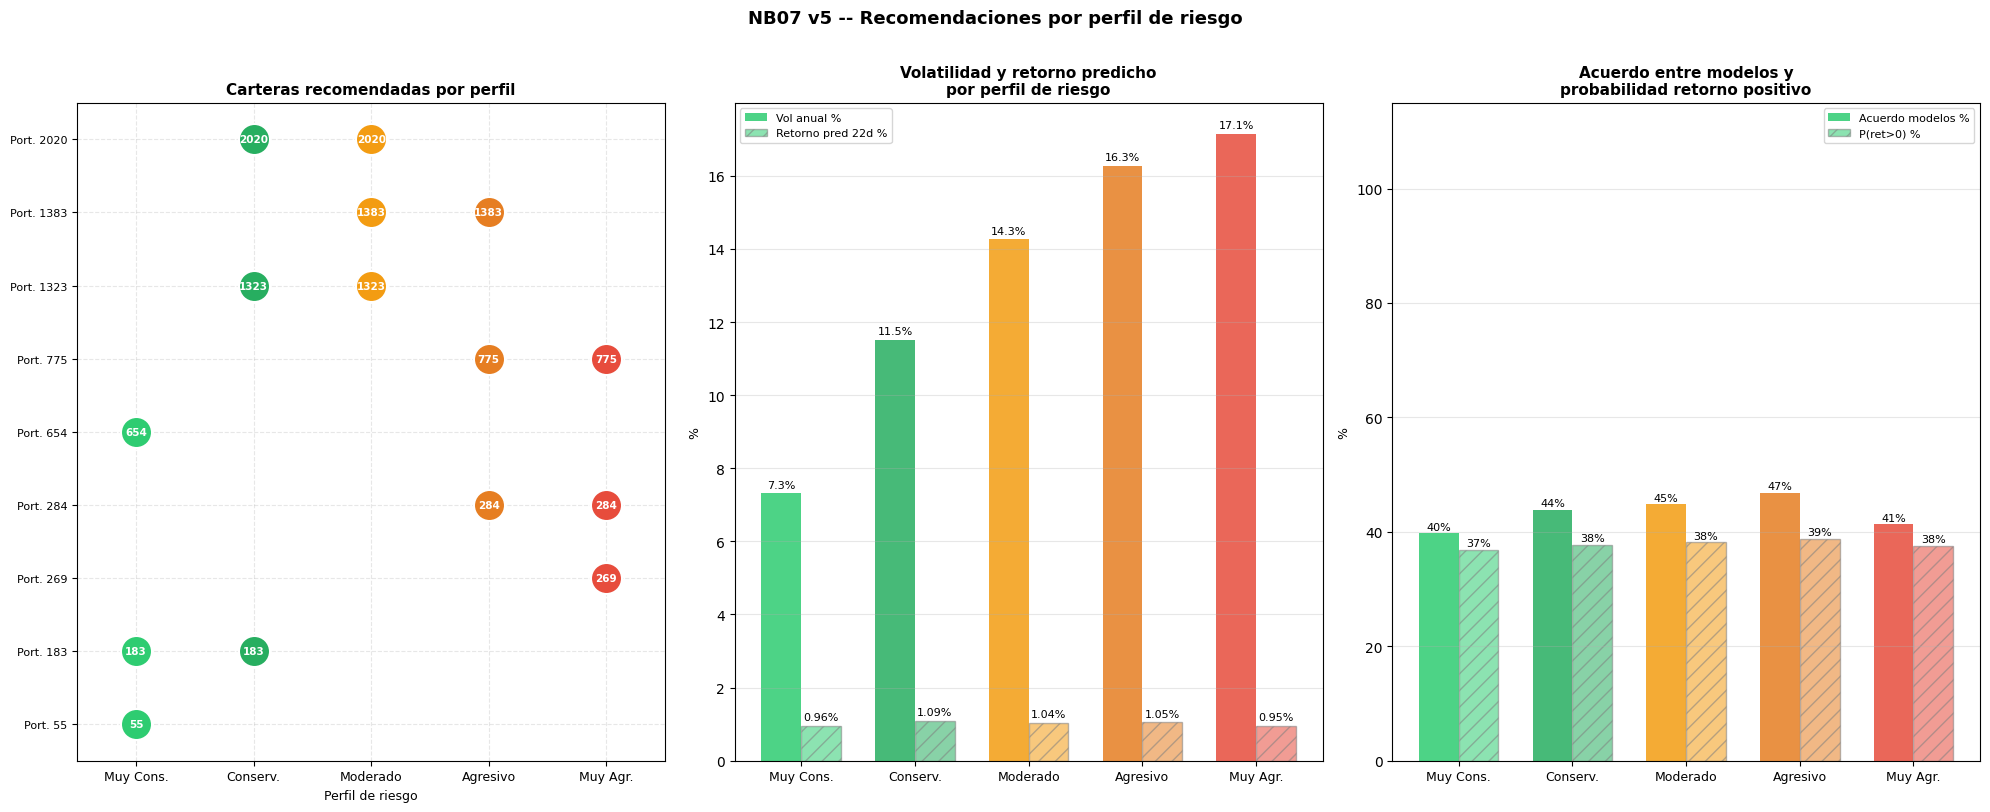

[OK] Guardado: 07_recommendations_summary.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

if 'all_recs' not in globals() or 'all_meta' not in globals():
    all_recs, all_meta = {}, {}
    rrs = regime_context['regime_risk_score']
    label = regime_context['current_regime_label']
    colors = {1:'#2ca02c', 2:'#98df8a', 3:'#ffbb78', 4:'#ff7f0e', 5:'#d62728'}
    for rl in range(1, 6):
        recs, meta = recommend_v5(pred_frame, rl, regime_context, top_n=3)
        all_recs[rl] = recs
        all_meta[rl] = meta
    print('[WARN] all_recs no estaba definido; se regeneró para la visualización')

# Recopilar datos de recomendaciones actuales
_rec_rows = []
for _rl, _recs in all_recs.items():
    for _, _row in _recs.iterrows():
        _vol = _row.get('pred_ann_vol', float('nan'))
        _rec_rows.append({
            'risk_level': _rl,
            'portfolio_id': int(_row['portfolio_id']),
            'score': float(_row['score']),
            'growth_pred': float(_row.get('growth_pred', 0)),
            'p_positive': float(_row.get('p_positive', 0)),
            'model_agreement': float(_row.get('model_agreement', 0)),
            'pred_ann_vol': float(_vol) if _vol is not None and not pd.isna(_vol) else 0.0,
            'is_cash': bool(_row.get('is_cash', False)),
        })
_rec_df = pd.DataFrame(_rec_rows)

_risk_colors = {1: '#2ecc71', 2: '#27ae60', 3: '#f39c12', 4: '#e67e22', 5: '#e74c3c'}
_risk_labels = {1: 'Muy Cons.', 2: 'Conserv.', 3: 'Moderado', 4: 'Agresivo', 5: 'Muy Agr.'}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Panel 1: matriz cartera x perfil
ax = axes[0]
_all_pids = sorted(_rec_df['portfolio_id'].unique())
_pid_to_y = {pid: i for i, pid in enumerate(_all_pids)}
for _, _row in _rec_df.iterrows():
    _rl = int(_row['risk_level'])
    _pid = int(_row['portfolio_id'])
    _x = _rl - 1
    _y = _pid_to_y[_pid]
    ax.scatter(_x, _y, s=500, color=_risk_colors[_rl], zorder=3,
               edgecolors='white', linewidths=1.5)
    ax.text(_x, _y, str(_pid), ha='center', va='center', fontsize=7.5,
            fontweight='bold', color='white', zorder=4)
ax.set_xticks(range(5))
ax.set_xticklabels([_risk_labels[i+1] for i in range(5)], fontsize=9)
ax.set_yticks(range(len(_all_pids)))
ax.set_yticklabels([f'Port. {p}' for p in _all_pids], fontsize=8)
ax.set_title('Carteras recomendadas por perfil', fontsize=11, fontweight='bold')
ax.set_xlabel('Perfil de riesgo', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, len(_all_pids) - 0.5)

# Panel 2: Vol historica y retorno predicho por perfil
ax2 = axes[1]
_rls = list(range(1, 6))
_vol_by_rl = [_rec_df[_rec_df['risk_level']==rl]['pred_ann_vol'].mean()*100 for rl in _rls]
_ret_by_rl = [_rec_df[_rec_df['risk_level']==rl]['growth_pred'].mean()*100 for rl in _rls]
_x_pos = np.arange(5)
_bar_w = 0.35
_bars_v = ax2.bar(_x_pos - _bar_w/2, _vol_by_rl, _bar_w,
                  color=[_risk_colors[i+1] for i in range(5)], alpha=0.85, label='Vol anual %')
_bars_r = ax2.bar(_x_pos + _bar_w/2, _ret_by_rl, _bar_w,
                  color=[_risk_colors[i+1] for i in range(5)], alpha=0.55,
                  hatch='//', edgecolor='gray', label='Retorno pred 22d %')
for _b, _v in zip(_bars_v, _vol_by_rl):
    if _v > 0:
        ax2.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.1,
                 f'{_v:.1f}%', ha='center', va='bottom', fontsize=8)
for _b, _v in zip(_bars_r, _ret_by_rl):
    if _v > 0:
        ax2.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.1,
                 f'{_v:.2f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(_x_pos)
ax2.set_xticklabels([_risk_labels[i+1] for i in range(5)], fontsize=9)
ax2.set_title('Volatilidad y retorno predicho\npor perfil de riesgo', fontsize=11, fontweight='bold')
ax2.set_ylabel('%', fontsize=9)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Acuerdo modelos y P(ret>0)
ax3 = axes[2]
_agree_by_rl = [_rec_df[_rec_df['risk_level']==rl]['model_agreement'].mean() for rl in _rls]
_pp_by_rl    = [_rec_df[_rec_df['risk_level']==rl]['p_positive'].mean() for rl in _rls]
_bars_a = ax3.bar(_x_pos - _bar_w/2, [v*100 for v in _agree_by_rl], _bar_w,
                  color=[_risk_colors[i+1] for i in range(5)], alpha=0.85,
                  label='Acuerdo modelos %')
_bars_p = ax3.bar(_x_pos + _bar_w/2, [v*100 for v in _pp_by_rl], _bar_w,
                  color=[_risk_colors[i+1] for i in range(5)], alpha=0.55,
                  hatch='//', edgecolor='gray', label='P(ret>0) %')
for _b, _v in zip(_bars_a, _agree_by_rl):
    ax3.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.3,
             f'{_v*100:.0f}%', ha='center', va='bottom', fontsize=8)
for _b, _v in zip(_bars_p, _pp_by_rl):
    ax3.text(_b.get_x()+_b.get_width()/2, _b.get_height()+0.3,
             f'{_v*100:.0f}%', ha='center', va='bottom', fontsize=8)
ax3.set_xticks(_x_pos)
ax3.set_xticklabels([_risk_labels[i+1] for i in range(5)], fontsize=9)
ax3.set_title('Acuerdo entre modelos y\nprobabilidad retorno positivo', fontsize=11, fontweight='bold')
ax3.set_ylabel('%', fontsize=9)
ax3.set_ylim(0, 115)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('NB07 v5 -- Recomendaciones por perfil de riesgo', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = FIG_DIR / '07_recommendations_summary.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'[OK] Guardado: {out_path.name}')

## 4. Generar recomendaciones por nivel de riesgo

In [7]:
all_recs, all_meta = {}, {}
rrs   = regime_context['regime_risk_score']
label = regime_context['current_regime_label']
print(f"Regimen actual: '{label}'  |  rrs={rrs:.3f}")
print()

colors = {1:'#2ca02c', 2:'#98df8a', 3:'#ffbb78', 4:'#ff7f0e', 5:'#d62728'}
for rl in range(1, 6):
    recs, meta = recommend_v5(pred_frame, rl, regime_context, top_n=3)
    all_recs[rl] = recs
    all_meta[rl] = meta
    print(f"Risk {rl} -- {LEVEL_NAMES_V2[rl]}")
    print(f"  w_safe={meta['w_safe']:.2f}  w_return={meta['w_return']:.2f}  w_util={meta['w_utility']:.2f}  candidatos={meta['n_candidates']}  cash={meta['cash_included']}")
    cols = [c for c in ['portfolio_id','score','utility_score','p_positive','growth_pred','pred_ann_vol','is_cash'] if c in recs.columns]
    print(recs[cols].round(4).to_string(index=False))
    print()

Regimen actual: 'Transition'  |  rrs=0.268

Risk 1 -- Muy Conservador (bajo error)
  w_safe=0.54  w_return=0.01  w_util=0.45  candidatos=5  cash=True
 portfolio_id  score  utility_score  p_positive  growth_pred  pred_ann_vol  is_cash
          183 0.9251         1.0000      0.3701       0.0120        0.0701    False
           55 0.7725         0.6666      0.3687       0.0080        0.0458    False
          654 0.5536         0.3277      0.3652       0.0089        0.1036    False

Risk 2 -- Conservador
  w_safe=0.64  w_return=0.01  w_util=0.35  candidatos=10  cash=True
 portfolio_id  score  utility_score  p_positive  growth_pred  pred_ann_vol  is_cash
         2020 0.7761         0.4746      0.3836       0.0097        0.1382    False
         1323 0.7414         0.5958      0.3795       0.0110        0.1373    False
          183 0.7354         1.0000      0.3701       0.0120        0.0701    False

Risk 3 -- Moderado
  w_safe=0.64  w_return=0.11  w_util=0.25  candidatos=10  cash=Fals

## 5. Diversidad de recomendaciones

In [8]:
seen = set()
for rl, recs in all_recs.items():
    ids = set(recs['portfolio_id'].astype(int).tolist())
    print(f"  Risk {rl}: {sorted(ids)}  nuevos={len(ids-seen)}")
    seen |= ids
print(f"Total carteras unicas recomendadas: {len(seen)}")

  Risk 1: [55, 183, 654]  nuevos=3
  Risk 2: [183, 1323, 2020]  nuevos=2
  Risk 3: [1323, 1383, 2020]  nuevos=1
  Risk 4: [284, 775, 1383]  nuevos=2
  Risk 5: [269, 284, 775]  nuevos=1
Total carteras unicas recomendadas: 9


## 6. Visualización

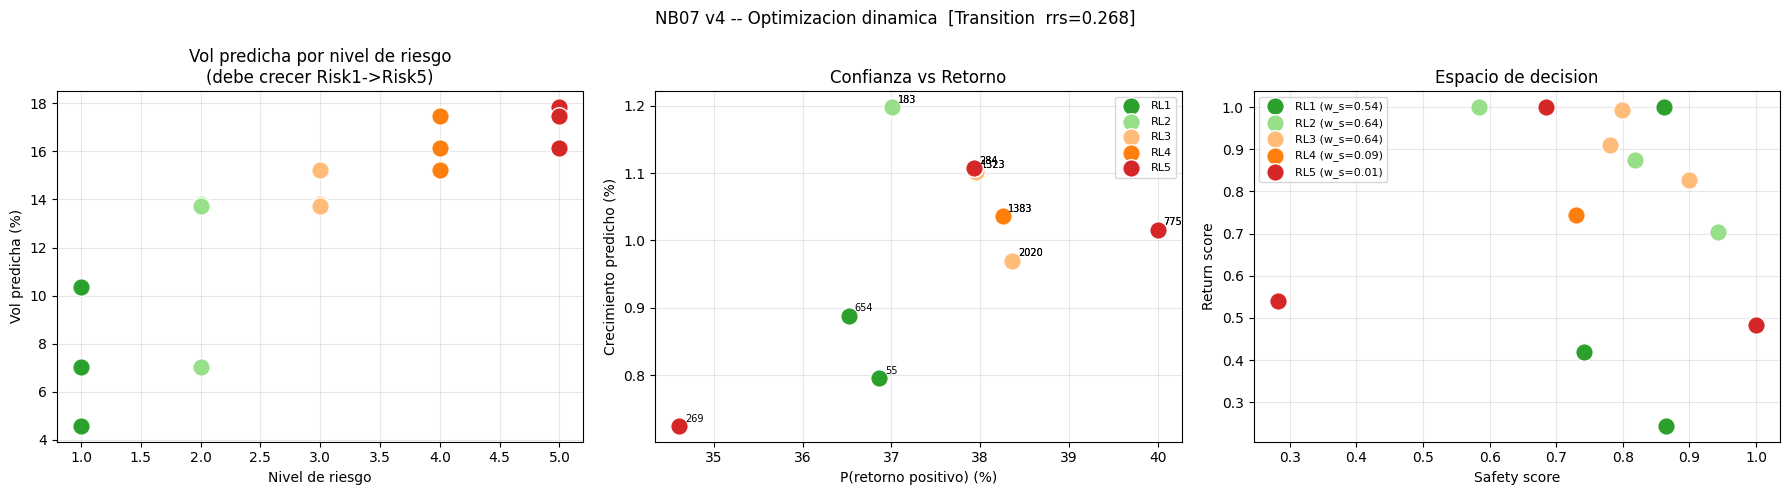

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for rl, recs in all_recs.items():
    if 'pred_ann_vol' in recs.columns:
        ax.scatter([rl]*len(recs), recs['pred_ann_vol']*100,
                   color=colors[rl], s=160, zorder=3, edgecolors='white', lw=1)
ax.set_xlabel('Nivel de riesgo'); ax.set_ylabel('Vol predicha (%)')
ax.set_title('Vol predicha por nivel de riesgo\n(debe crecer Risk1->Risk5)')
ax.grid(alpha=0.3)

ax = axes[1]
for rl, recs in all_recs.items():
    ax.scatter(recs['p_positive']*100, recs['growth_pred']*100,
               color=colors[rl], s=160, zorder=3, edgecolors='white', lw=1, label=f'RL{rl}')
    for _, row in recs.iterrows():
        ax.annotate(str(int(row['portfolio_id'])),
                    (row['p_positive']*100, row['growth_pred']*100),
                    textcoords='offset points', xytext=(4,3), fontsize=7)
ax.set_xlabel('P(retorno positivo) (%)'); ax.set_ylabel('Crecimiento predicho (%)')
ax.set_title('Confianza vs Retorno')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
if all('safety_score' in r.columns and 'return_score' in r.columns for r in all_recs.values()):
    for rl, recs in all_recs.items():
        ax.scatter(recs['safety_score'], recs['return_score'],
                   color=colors[rl], s=160, zorder=3, edgecolors='white', lw=1,
                   label=f"RL{rl} (w_s={all_meta[rl]['w_safe']:.2f})")
    ax.set_xlabel('Safety score'); ax.set_ylabel('Return score')
    ax.set_title('Espacio de decision')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"NB07 v4 -- Optimizacion dinamica  [{label}  rrs={rrs:.3f}]", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_recommendations_v2.png', dpi=150)
plt.show()

## 7. Guardar outputs

In [10]:
recs_df = pd.concat([r.assign(risk_level=rl) for rl, r in all_recs.items()], ignore_index=True)

# Guardar v4 (principal) + v2 (compatibilidad con NB08)
recs_df.to_parquet(RESULTS_DIR / "recommendations_v8.parquet", index=False)
print("[OK] recommendations_v8.parquet")

def _to_native(v):
    if hasattr(v, "item"): return v.item()
    if isinstance(v, (int, float, str, bool, type(None))): return v
    return str(v)

engine = {
    "last_update":     pd.Timestamp.now().isoformat(),
    "version":         "v6",
    "source_version":  source_version,
    "vol_model_used":  vol_model_used,
    "regime_context":  {k: _to_native(v) for k, v in regime_context.items()},
    "vol_tier_quantiles": {str(k): list(v) for k, v in VOL_TIER_QUANTILE.items()},
    "meta":            {str(rl): {k: _to_native(v) for k, v in m.items()} for rl, m in all_meta.items()},
    "recommendations": {str(rl): r.to_dict(orient="records") for rl, r in all_recs.items()},
}
with open(RESULTS_DIR / "recommendation_engine_v6.json", "w") as f:
    json.dump(engine, f, indent=2, default=str)
print("[OK] recommendation_engine_v5.json")

label  = regime_context["current_regime_label"]
rrs    = regime_context["regime_risk_score"]
print(f"NB07 v6 COMPLETE -- regimen={label!r}  rrs={rrs:.3f}  "
      f"vol_model={vol_model_used}  carteras_unicas={len(seen)}")


[OK] recommendations_v8.parquet
[OK] recommendation_engine_v5.json
NB07 v6 COMPLETE -- regimen='Transition'  rrs=0.268  vol_model=CAT_vol  carteras_unicas=9
